In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("../data/GDELT_events_benin_2025_cleaned.csv", low_memory=False)
df["event_date"] = pd.to_datetime(df["SQLDATE"].astype(str), errors="coerce")

In [2]:
# Construction des features par pays partenaire
ATTRACTIVITY_ROOTS = {"01","02","03","04","05","06","07"}

partner_df = df[
    ~df["Actor1CountryCode"].isin(["BEN", "", None]) &
    df["Actor1CountryCode"].notna()
].copy()

features = (
    partner_df.groupby("Actor1CountryCode")
    .agg(
        volume=("GLOBALEVENTID", "count"),
        avg_tone=("AvgTone", "mean"),
        avg_gold=("GoldsteinScale", "mean"),
        pct_coop=("QuadClass", lambda x: (x.isin([1, 2])).mean()),
        n_sources=("NumSources", "mean"),
    )
    .reset_index()
)

# Garder uniquement les pays avec volume suffisant
features = features[features["volume"] >= 10].copy()
print(f"{len(features)} pays partenaires avec volume ≥ 10 événements")
features.head()

60 pays partenaires avec volume ≥ 10 événements


,Actor1CountryCode,volume,avg_tone,avg_gold,pct_coop,n_sources
0,AFR,757,-0.311778,1.224703,0.754293,1.023778
2,ARE,13,-10.682780,-2.630769,0.538462,1.000000
10,BEL,27,1.220187,3.422222,0.925926,1.074074
11,BFA,177,-3.439511,-1.479661,0.525424,1.005650
15,BRA,40,1.675969,2.282500,0.950000,1.000000


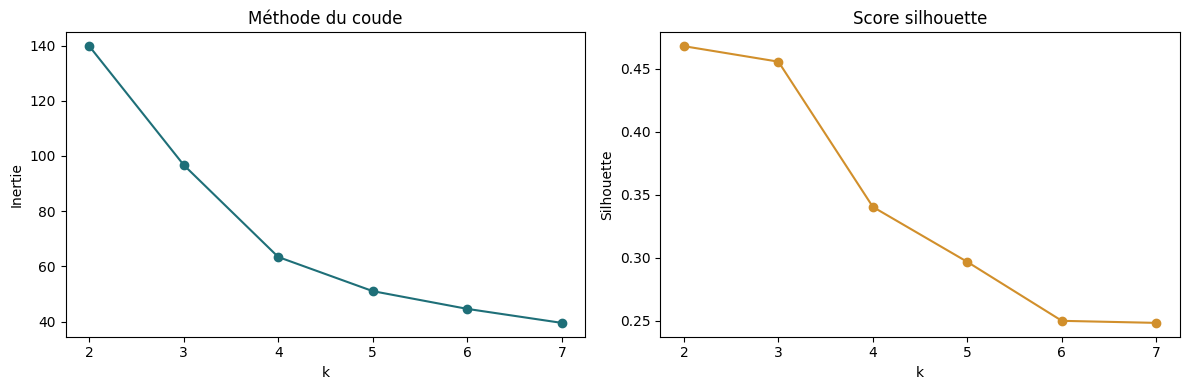

Meilleur k selon silhouette : 2


In [4]:
# Choix du nombre de clusters (méthode du coude + silhouette)
X = features[["volume", "avg_tone", "avg_gold", "pct_coop"]].fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertias, silhouettes = [], []
K_range = range(2, 8)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(K_range, inertias, marker='o', color='#1e6f78')
axes[0].set_title("Méthode du coude")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertie")

axes[1].plot(K_range, silhouettes, marker='o', color='#d18f2b')
axes[1].set_title("Score silhouette")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette")

plt.tight_layout()
plt.savefig("img_6/fig_elbow.png", dpi=130)
plt.show()
print(f"Meilleur k selon silhouette : {K_range[np.argmax(silhouettes)]}")

In [5]:
# Clustering final avec k=4
K_FINAL = 4
km = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
features["cluster"] = km.fit_predict(X_scaled)

# Nommage sémantique des clusters selon leurs centroïdes
centroids = pd.DataFrame(
    scaler.inverse_transform(km.cluster_centers_),
    columns=["volume", "avg_tone", "avg_gold", "pct_coop"]
)

CLUSTER_LABELS = {}
for i, row in centroids.iterrows():
    if row["avg_tone"] > 0 and row["pct_coop"] > 0.6:
        CLUSTER_LABELS[i] = "Partenaires stables positifs"
    elif row["volume"] == centroids["volume"].max():
        CLUSTER_LABELS[i] = "Partenaires dominants"
    elif row["avg_tone"] < 0 and row["avg_gold"] < 0:
        CLUSTER_LABELS[i] = "Partenaires à risque"
    else:
        CLUSTER_LABELS[i] = "Partenaires émergents"

features["cluster_label"] = features["cluster"].map(CLUSTER_LABELS)
print(features.groupby("cluster_label")[["volume","avg_tone","avg_gold","pct_coop"]].mean().round(2))

                               volume  avg_tone  avg_gold  pct_coop
cluster_label                                                      
Partenaires dominants         2250.00     -1.48      0.67      0.76
Partenaires stables positifs    37.04      1.79      3.48      0.95
Partenaires à risque            98.83     -4.86     -1.68      0.52
Partenaires émergents          128.08     -0.46      1.49      0.80


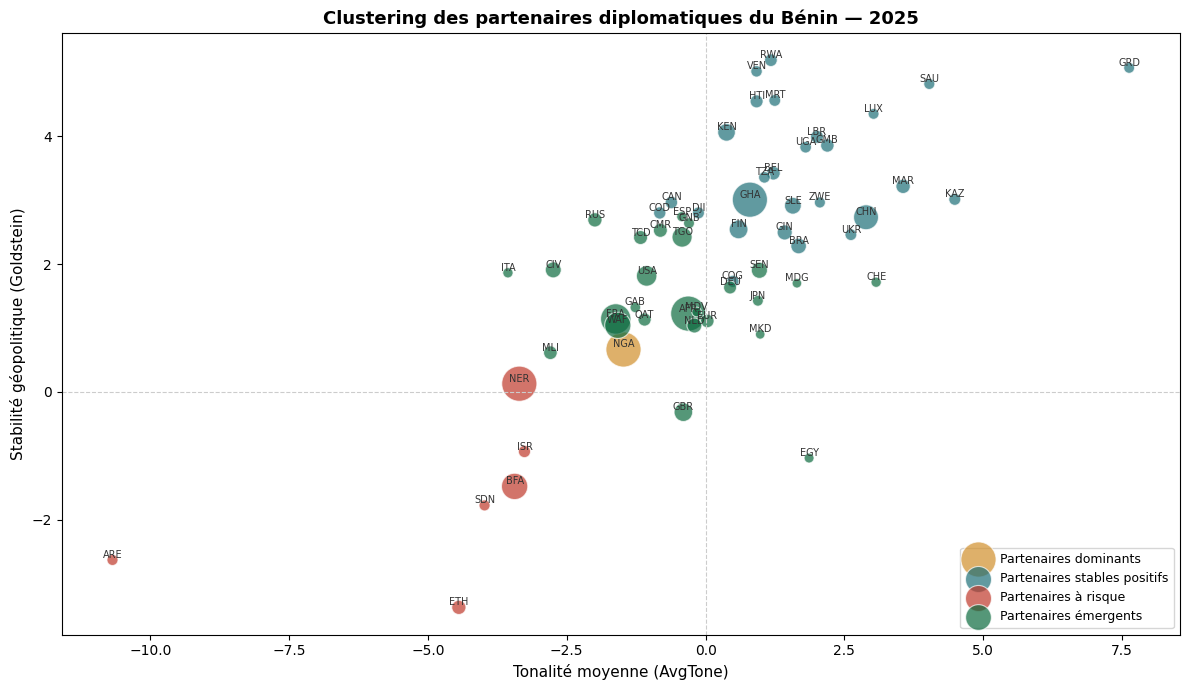

In [6]:
# Visualisation
COLORS = {
    "Partenaires stables positifs": "#1e6f78",
    "Partenaires dominants":        "#d18f2b",
    "Partenaires à risque":         "#c0392b",
    "Partenaires émergents":        "#0d6b3f",
}

fig, ax = plt.subplots(figsize=(12, 7))
for label, grp in features.groupby("cluster_label"):
    ax.scatter(
        grp["avg_tone"], grp["avg_gold"],
        s=grp["volume"] / grp["volume"].max() * 600 + 40,
        color=COLORS.get(label, "#888"),
        alpha=0.7, label=label, edgecolors="white", linewidths=0.8
    )
    for _, row in grp.iterrows():
        ax.annotate(
            row["Actor1CountryCode"],
            (row["avg_tone"], row["avg_gold"]),
            fontsize=7, ha="center", va="bottom", color="#333"
        )

ax.axhline(0, color="#ccc", linewidth=0.8, linestyle="--")
ax.axvline(0, color="#ccc", linewidth=0.8, linestyle="--")
ax.set_xlabel("Tonalité moyenne (AvgTone)", fontsize=11)
ax.set_ylabel("Stabilité géopolitique (Goldstein)", fontsize=11)
ax.set_title("Clustering des partenaires diplomatiques du Bénin — 2025", fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig("img_6/fig_clustering.png", dpi=130)
plt.show()

In [7]:
# Cellule 6 — Insights actionnables
print("=== INSIGHTS CLUSTERING DIPLOMATIQUE ===\n")
for label, grp in features.groupby("cluster_label"):
    pays = ", ".join(grp.sort_values("volume", ascending=False)["Actor1CountryCode"].head(5))
    print(f" {label} ({len(grp)} pays)")
    print(f"   Top pays : {pays}")
    print(f"   Ton moy : {grp['avg_tone'].mean():+.2f} | Goldstein : {grp['avg_gold'].mean():+.2f} | Coop : {grp['pct_coop'].mean():.0%}")
    if label == "Partenaires stables positifs":
        print("   → Priorité pour des accords bilatéraux et IDE. Signal médiatique favorable.")
    elif label == "Partenaires à risque":
        print("   → Surveiller l'évolution. Envisager un dialogue diplomatique proactif.")
    elif label == "Partenaires émergents":
        print("   → Opportunités à développer. Faible volume mais signal positif.")
    elif label == "Partenaires dominants":
        print("   → Volume fort mais à nuancer (biais médiatique possible).")
    print()

=== INSIGHTS CLUSTERING DIPLOMATIQUE ===

 Partenaires dominants (1 pays)
   Top pays : NGA
   Ton moy : -1.48 | Goldstein : +0.67 | Coop : 76%
   → Volume fort mais à nuancer (biais médiatique possible).

 Partenaires stables positifs (27 pays)
   Top pays : GHA, CHN, FIN, KEN, SLE
   Ton moy : +1.79 | Goldstein : +3.48 | Coop : 95%
   → Priorité pour des accords bilatéraux et IDE. Signal médiatique favorable.

 Partenaires à risque (6 pays)
   Top pays : NER, BFA, ETH, ISR, ARE
   Ton moy : -4.86 | Goldstein : -1.68 | Coop : 52%
   → Surveiller l'évolution. Envisager un dialogue diplomatique proactif.

 Partenaires émergents (26 pays)
   Top pays : AFR, FRA, WAF, USA, TGO
   Ton moy : -0.46 | Goldstein : +1.49 | Coop : 80%
   → Opportunités à développer. Faible volume mais signal positif.

